In [1]:
import numpy as np
import mogptk
import matplotlib.pyplot as plt
import random
seed = 100
random.seed(seed)
np.random.seed(seed)

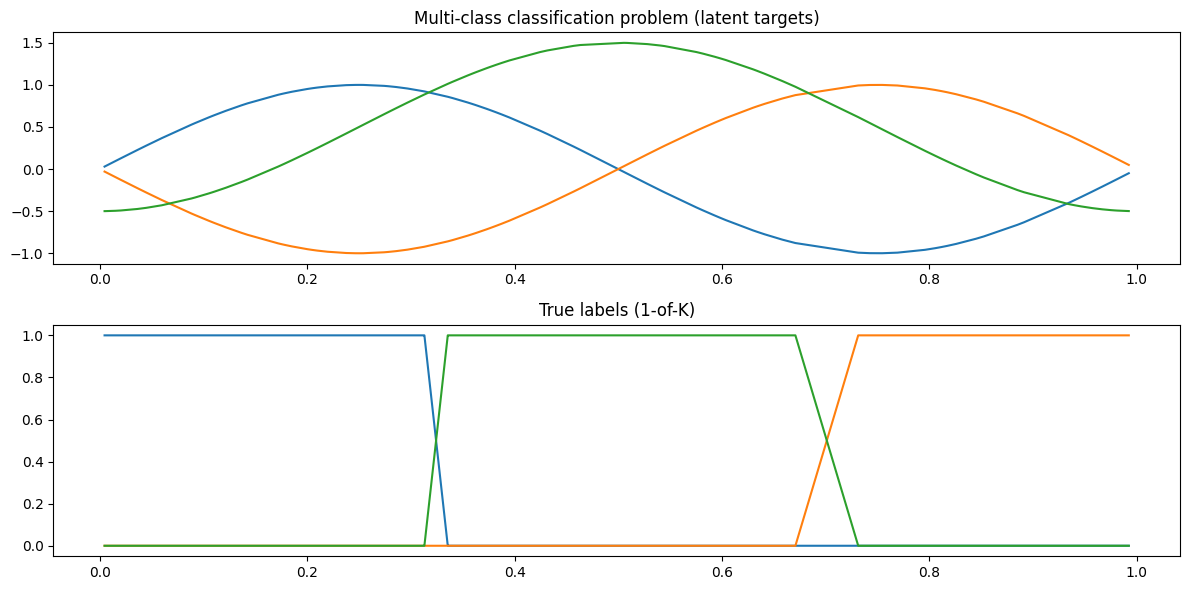

N = 100 K = 3


In [2]:
# Cell 3 — Problema multiclase 1D (idéntico al demo GPflow)

N = 100
X = np.random.rand(N, 1)

t1 = (np.sin(2 * np.pi * X)).reshape(N, 1)
t2 = (-np.sin(2 * np.pi * X)).reshape(N, 1)
t3 = (-np.sin(2 * np.pi * (X + 0.25)) + 0.5).reshape(N, 1)

t = np.concatenate((t1, t2, t3), axis=1)

idx = np.argsort(X, axis=0).flatten()
X = X[idx]
t = t[idx, :]

y = (np.argmax(t, axis=1).reshape(-1, 1).astype(float) + 1)  # labels 1..K
K = len(np.unique(y))

def one_of_K(y, K):
    Yhat = np.ones((y.shape[0], K))
    for k in range(K):
        Yhat[:, k, None] = (y == k + 1).astype(int)
    return Yhat

Yhat = one_of_K(y, K)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(X, t)
plt.title("Multi-class classification problem (latent targets)")
plt.subplot(2, 1, 2)
plt.plot(X, Yhat)
plt.title("True labels (1-of-K)")
plt.tight_layout()
plt.show()

print("N =", N, "K =", K)

In [3]:
# Cell 4 — Train/Test set (idéntico al demo)

seed = 1
np.random.seed(seed)

Ntest = 200

# Training set (ya lo tienes en X, y)
Xtrain = X.reshape((N, 1))
ytrain = y

# Test set
Xtest = np.linspace(0, 1, Ntest).reshape((Ntest, 1))

t1 = (np.sin(2 * np.pi * Xtest)).reshape(Ntest, 1)
t2 = (-np.sin(2 * np.pi * Xtest)).reshape(Ntest, 1)
t3 = (-np.sin(2 * np.pi * (Xtest + 0.25)) + 0.5).reshape(Ntest, 1)

ttest = np.concatenate((t1, t2, t3), axis=1)
ytest = (np.argmax(ttest, axis=1).reshape(-1, 1).astype(float) + 1)  # labels 1..K

print("Xtrain:", Xtrain.shape, "ytrain:", ytrain.shape)
print("Xtest :", Xtest.shape, "ytest :", ytest.shape)

Xtrain: (100, 1) ytrain: (100, 1)
Xtest : (200, 1) ytest : (200, 1)


In [4]:
# Cell 5 — Simulación de múltiples anotadores (copiado del utils.py del demo)

def Sigmoid(f_r):
    return 1 / (1 + np.exp(-f_r))

def multiple_annotators(R, NrP, Xtrain, ytrain):
    N = Xtrain.size
    Kloc = len(np.unique(ytrain))

    # latent factor functions u_q
    u_q = np.empty((Xtrain.shape[0], 3))
    u_q[:, 0, None] = (
        4.5 * np.cos(2 * np.pi * Xtrain + 1.5 * np.pi)
        - 3 * np.sin(4.3 * np.pi * Xtrain + 0.3 * np.pi)
    )
    u_q[:, 1, None] = (
        4.5 * np.cos(1.5 * np.pi * Xtrain + 0.5 * np.pi)
        + 5 * np.sin(3 * np.pi * Xtrain + 1.5 * np.pi)
    )
    u_q[:, 2, None] = 1

    # combination weights W[q][r]
    W = []
    W.append(np.array(([[0.4], [0.7], [-0.5], [0], [-0.7]])))     # q=1
    W.append(np.array(([[0.4], [-1.0], [-0.1], [-0.8], [1.0]])))  # q=2
    W.append(np.array(([[3.1], [-1.8], [-0.6], [-1.2], [1.0]])))  # q=3

    Lam_r = []
    for r in range(R):
        f_r = np.zeros((Xtrain.shape[0], 1))
        for q in range(3):
            f_r += W[q][r].T * u_q[:, q, None]
        lam_r = Sigmoid(f_r)
        lam_r[lam_r > 0.5] = 1
        lam_r[lam_r <= 0.5] = 0
        Lam_r.append(lam_r)

    # Simulate annotations (Ytrain is always 1..K for all entries, like demo)
    seed = 100
    np.random.seed(seed)
    Ytrain = np.ones((N, R))
    for r in range(R):
        aux = ytrain.copy()
        for n in range(N):
            if Lam_r[r][n] == 0:
                labels = np.arange(1, Kloc + 1)
                a = np.where(labels == ytrain[n])
                labels = np.delete(labels, a)
                idxlabels = np.random.permutation(Kloc - 1)
                aux[n] = labels[idxlabels[0]]
        Ytrain[:, r] = aux.flatten()

    # Annotation mask iAnn
    seed = 100
    np.random.seed(seed)
    iAnn = np.zeros((N, R), dtype=int)
    Nr = np.ones((R), dtype=int) * int(np.floor(N * NrP))
    for r in range(R):
        if r < R - 1:
            indexR = np.random.permutation(range(N))[: Nr[r]]
            iAnn[indexR, r] = 1
        else:
            iSimm = np.sum(iAnn, axis=1)
            idxZero = np.asarray([i for (i, val) in enumerate(iSimm) if val == 0])
            Nzeros = idxZero.shape[0]
            idx2Choose = np.arange(N)
            if Nzeros == 0:
                indexR = np.random.permutation(range(N))[: Nr[r]]
                iAnn[indexR, r] = 1
            else:
                idx2Choose = np.delete(idx2Choose, idxZero)
                N2chose = idx2Choose.shape[0]
                idxNoZero = np.random.permutation(N2chose)[: (Nr[r] - Nzeros)]
                idxTot = np.concatenate((idxZero, idx2Choose[idxNoZero]))
                iAnn[idxTot, r] = 1

    # Demo intent: all samples labeled at least once (note: demo has a bug: doesn't raise)
    iSimm = np.sum(iAnn, axis=1)
    if (iSimm == 0).any():
        raise ValueError("all the samples must be labeled at least once")

    Vref = -1e-20
    return Lam_r, Ytrain, iAnn, Vref


R = 5      # number of annotators
NrP = 1.0  # percentage labeled by each annotator (start with 1.0 like a sanity check)

Z_r, Ytrain, iAnn, Vref = multiple_annotators(R, NrP, Xtrain, ytrain)

print("Ytrain:", Ytrain.shape, "iAnn:", iAnn.shape, "Vref:", Vref)
print("Unique labels in Ytrain:", np.unique(Ytrain))
print("iAnn sums per annotator:", iAnn.sum(axis=0))
print("iAnn sums per point min/max:", iAnn.sum(axis=1).min(), iAnn.sum(axis=1).max())

Ytrain: (100, 5) iAnn: (100, 5) Vref: -1e-20
Unique labels in Ytrain: [1. 2. 3.]
iAnn sums per annotator: [100 100 100 100 100]
iAnn sums per point min/max: 5 5


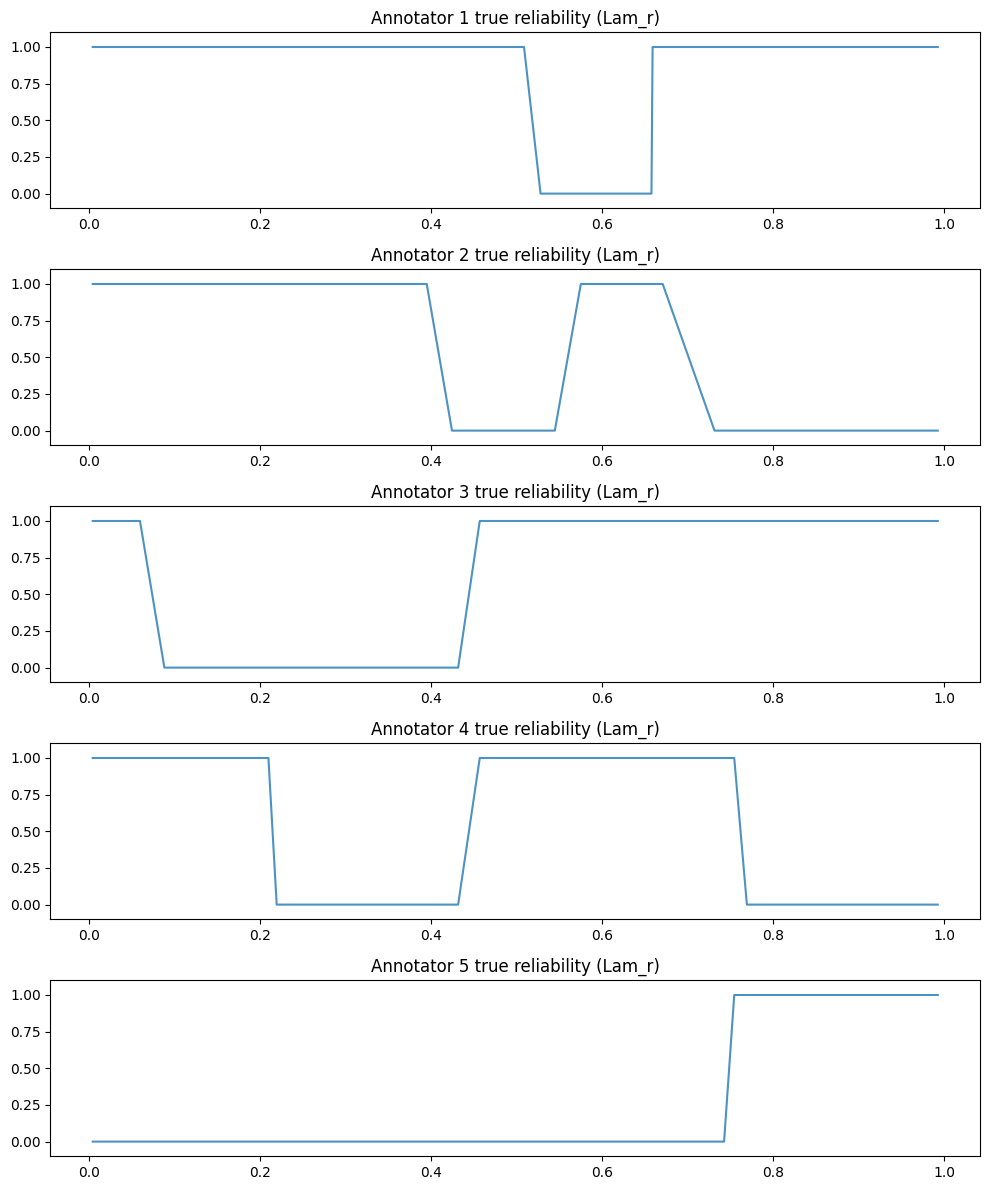

In [5]:
# Cell 6 — Plot de "confiabilidad verdadera" (Lam_r) como en el demo

plt.figure(figsize=(10, 12))
for r in range(R):
    plt.subplot(R, 1, r + 1)
    plt.plot(Xtrain, Z_r[r], alpha=0.8)
    plt.ylim(-0.1, 1.1)
    plt.title(f"Annotator {r+1} true reliability (Lam_r)")
plt.tight_layout()
plt.show()

In [6]:
# Cell 7 — Pasar datos a torch (esto casi seguro lo necesitarás para tu likelihood)

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

Xtr = torch.tensor(Xtrain, dtype=dtype, device=device)
Ytr = torch.tensor(Ytrain, dtype=dtype, device=device)   # (N, R) en {1..K}
iAnn_t = torch.tensor(iAnn, dtype=dtype, device=device)  # (N, R) en {0,1}

Xte = torch.tensor(Xtest, dtype=dtype, device=device)

print("device:", device)
print("Xtr:", Xtr.shape, Xtr.dtype)
print("Ytr:", Ytr.shape, Ytr.dtype, "min/max:", Ytr.min().item(), Ytr.max().item())
print("iAnn:", iAnn_t.shape, iAnn_t.dtype, "unique:", torch.unique(iAnn_t).tolist())

device: cpu
Xtr: torch.Size([100, 1]) torch.float32
Ytr: torch.Size([100, 5]) torch.float32 min/max: 1.0 3.0
iAnn: torch.Size([100, 5]) torch.float32 unique: [1.0]


In [7]:
# Cell 8 — Importa tu likelihood (ajusta el import a TU proyecto)

# Opción A: si tu clase está en un archivo local, ejemplo:
# from my_likelihoods.multiclass_ma import MultiClassMA

# Opción B: si la metiste dentro de mogptk (p.ej. mogptk/gpr/likelihood.py),
# entonces debería ser algo como:
from mogptk.gpr.likelihood import MultiClassMA

# ---- AJUSTA ESTAS 2 LÍNEAS ----
#from mogptk.gpr.likelihood import MultiClassMA  # <-- cambia si tu ruta es distinta

lik = MultiClassMA(K=K, R=R, iAnn=iAnn_t, beta=0.1, use_gce=True)

print(lik.name() if hasattr(lik, "name") else lik)

MultiClassMA(beta=0.1, K=3, R=5, Q=8)


In [8]:
# Cell 9 — Smoke test: validate_y (debe pasar sin errores)

# Dependiendo de la firma real en mogptk, puede ser validate_y(y) o validate_y(X,y).
# Nosotros lo definimos como validate_y(X, y).
lik.validate_y(Xtr, Ytr)
print("validate_y OK")

validate_y OK


Built mogptk dataset with channels: 8


<Axes: title={'center': 'Placeholder y (majority vote) — channel 1/8'}, xlabel='X', ylabel='Y'>

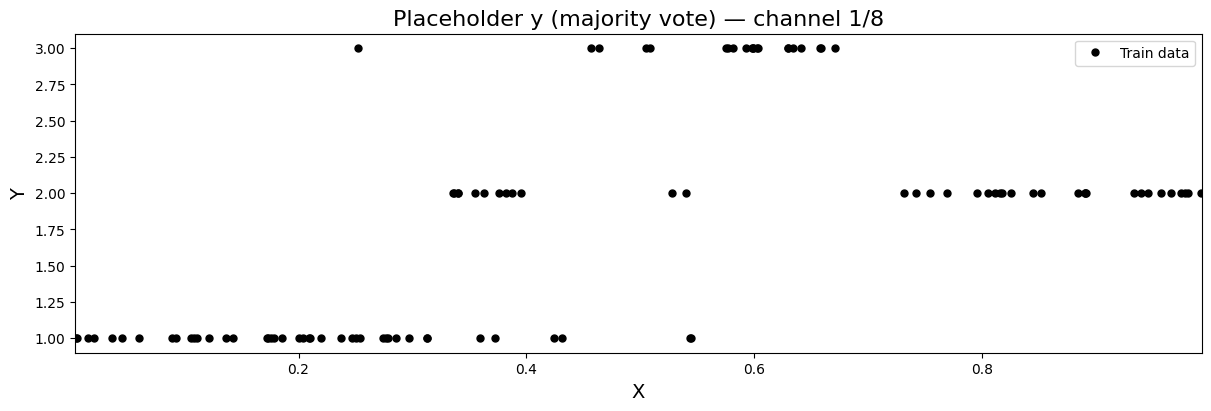

In [9]:
# Cell 10 — Construir el DataSet para mogptk (MultiClassMA, demo-style)

# En mogptk, cada "canal" suele corresponder a una salida/latent.
# Para MultiClassMA tenemos Q = K + R latentes, pero OJO:
#   - y observado (datos) es Ytrain de shape (N, R) (no 1 columna por canal).
#   - Nuestro likelihood usa y=(N,R) y self.iAnn (N,R).
#
# Entonces: para alimentar mogptk sin pelearse con su API, vamos a crear Q canales
# con el MISMO y placeholder (una columna), porque el likelihood realmente ignora
# ese "y por canal" y usará el y completo (N,R) que le pasemos al modelo.
#
# Pero como todavía estamos cerrando integración, en esta celda construiremos:
#   - y_placeholder: (N,1) con majority vote (o ceros) solo para satisfacer Data(...)
#   - y_full: Ytrain (N,R) lo guardamos aparte para pasarlo al likelihood/metadata si tu wrapper lo soporta

def MAjVot(Y, K):
    Nloc, Rloc = Y.shape
    Yhat = np.zeros((Nloc, 1))
    for n in range(Nloc):
        votes = np.zeros((K, 1))
        for r in range(Rloc):
            for k in range(K):
                if Y[n, r] == k + 1:
                    votes[k] = votes[k] + 1
        Yhat[n] = np.argmax(votes) + 1
    return Yhat

# majority vote label (N,1) solo para construir Data() por canal
y_mv = MAjVot(Ytrain, K).astype(float)

Q = K + R
dataset_items = []
for q in range(Q):
    dataset_items.append(mogptk.Data(Xtrain, y_mv, name=f"MA demo channel {q+1}/{Q}"))

data = mogptk.DataSet(*dataset_items)

print("Built mogptk dataset with channels:", len(data))
data[0].plot(title=f"Placeholder y (majority vote) — channel 1/{Q}")

In [10]:
# Cell 11 — Kernel: LMC para Q = K + R latentes (como tu demo, pero con Q canales)

# Creamos un kernel base por canal/latent
kernels = [mogptk.gpr.SquaredExponentialKernel() for _ in range(Q)]

# LMC con output_dims=Q
kernel = mogptk.gpr.LinearModelOfCoregionalizationKernel(*kernels, output_dims=Q)

print("Q =", Q)
print(kernel)

Q = 8
LinearModelOfCoregionalizationKernel(
  (kernels): ModuleList(
    (0-7): 8 x SquaredExponentialKernel()
  )
)


In [11]:
# Cell 12 — Inference + Model (igual que tu patrón)

# Importante: aquí todavía estamos usando el placeholder y_mv en el DataSet,
# porque tu wrapper aún no recibe y (N,R). Por ahora esto es un "smoke test"
# para verificar que el grafo de entrenamiento corre.
#
# En la siguiente etapa modificaremos el wrapper para que el likelihood vea Ytrain (N,R)
# y entonces este demo ya será "real".

# Asegúrate de que `lik` ya exista (tu MultiClassMA) y que tenga iAnn seteado.
# ej: lik = MultiClassMA(K=K, R=R, iAnn=torch.tensor(iAnn).float())

inference = mogptk.Hensman(likelihood=lik)

model = mogptk.Model(data, kernel, inference=inference)

print(model)

C:\Users\Usuario UTP\mogptk\mogptk\gpr\likelihood.py:1707: UserWarning: [MultiClassMA.validate_y] Demo is 1D but X has D=2 columns.
  warnings.warn(


ValueError: y must have R=5 columns (annotators). Got (800, 1)